# Recolección y Preparación de Datos
**Proyecto:** Segmentación automática de columna vertebral en radiografías  
**Tarea ClickUp:** [86aggyj9m](https://app.clickup.com/t/86aggyj9m) — Semana 1, Fase 1  
**Maestría en Inteligencia Artificial (MaIA) — Universidad de los Andes**

---

## ¿Qué hace este notebook?

Este notebook es el punto de partida del proyecto. Antes de entrenar cualquier modelo de inteligencia artificial, es imprescindible conocer en detalle los datos con los que se va a trabajar: cuántas imágenes hay, cómo están organizadas, qué calidad tienen, si existen errores o inconsistencias, y en qué formato espera los datos cada modelo.

El objetivo concreto es tomar el dataset `MaIA_Scoliosis_Dataset` —un conjunto de ~250 radiografías de columna vertebral con anotaciones de vértebras realizadas por radiólogos expertos— y dejarlo listo en tres formatos distintos para entrenar:

1. **YOLO11m-seg** — modelo CNN de una sola etapa, muy eficiente
2. **SegFormer-B2** — modelo basado en Transformers con atención global
3. **MedSAM** — modelo fundacional de segmentación médica (SAM adaptado)

## Estructura real del dataset

```
MaIA_Scoliosis_Dataset/
├── Normal/                       # 71 radiografías sanos        → N_1.jpg, N_2.jpg ...
├── Scoliosis/                    # 179 radiografías escoliosis   → S_100.jpg, S_101.jpg ...
├── LabelBinaryJPG/               # 250 máscaras binarias         → Label_N_1.jpg / Label_S_100.jpg
├── LabelMultiClass_ID_PNG/       # 250 máscaras multiclase uint16  ← USAR PARA ENTRENAMIENTO
│                                 #   → LabelMulti_N_1.png / LabelMulti_S_100.png
├── LabelMultiClass_Gray_JPG/     # versión visible en grises (solo inspección)
├── LabelMultiClass_Color_JPG/    # versión visible en color   (solo inspección)
├── RadiographMetrics/
│   ├── metrics_json/             # métricas por imagen (ángulo de Cobb, CSVL…)
│   ├── curves_csv/               # curvas de curvatura de la columna
│   ├── overlays/ y overlays_metrics/
└── labels_dictionary.json        # mapeo numérico ID → nombre de vértebra
```

**Codificación de las máscaras multiclase:**  
`0`=fondo · `1`=C7 · `2`=C6 · `3`=C5 · `4`=C4 · `5`=C3 · `6`=T1 … `17`=T12 · `18`=L1 … `22`=L5

## Secciones del notebook

1. Configuración del entorno y rutas  
2. Inventario del dataset  
3. Análisis de distribución y ángulo de Cobb  
4. Inspección visual de imágenes y máscaras  
5. Control de calidad  
6. Normalización y preprocesamiento  
7. División train / val / test  
8. Exportación por modelo  
9. Resumen y próximos pasos

---
## 1. Configuración del entorno y rutas

### 1.1 Instalación de dependencias

El primer paso es asegurarse de que todas las librerías necesarias estén disponibles. Se instalan con `pip` en modo silencioso (`-q`):

- **numpy / pandas** — manipulación numérica y tabular
- **matplotlib / seaborn** — visualización estadística
- **Pillow (PIL)** — lectura de imágenes PNG de 16 bits. Las máscaras multiclase son `uint16` y OpenCV las truncaría a `uint8` silenciosamente, corrompiendo los IDs de vértebras
- **scikit-learn** — `train_test_split` con estratificación
- **opencv-python-headless** — CLAHE, contornos para YOLO, conversión de color
- **tqdm** — barras de progreso en los bucles de exportación

### 1.2 Importación de librerías y semilla aleatoria

Se importan todos los módulos necesarios. El `SEED = 42` garantiza que cualquier operación aleatoria —muestreo para visualizaciones, división del dataset— produzca siempre el mismo resultado, haciendo el experimento reproducible.

In [33]:
import os, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED)
print('✅ Entorno listo')

✅ Entorno listo


### 1.3 Definición de rutas

Aquí se define **la única variable que hay que cambiar** al ejecutar el notebook en un entorno diferente: `DATASET_ROOT`, que apunta a la carpeta raíz del dataset.

A partir de esa ruta raíz se derivan automáticamente todas las subcarpetas. Esto evita tener rutas dispersas por el código; cualquier cambio de ubicación solo requiere modificar un único lugar.

También se carga `labels_dictionary.json`, el mapa oficial de correspondencias entre valores numéricos de píxel y nombre de vértebra. Por ejemplo, el píxel con valor `6` en una máscara corresponde a la vértebra `T1`. Este diccionario fue generado junto con el dataset y es la fuente de verdad para interpretar las máscaras.

Las claves con ID > 22 en el diccionario corresponden a artefactos del proceso de anotación y se descartan; solo se conservan las 22 clases anatómicas relevantes (C3–C7, T1–T12, L1–L5).

In [35]:
# ─────────────────────────────────────────────────────────────
# ÚNICA VARIABLE A AJUSTAR según entorno de ejecución:
#   Google Colab: /content/drive/MyDrive/maia/MaIA_Scoliosis_Dataset
#   Kaggle:       /kaggle/input/maia-scoliosis/MaIA_Scoliosis_Dataset
#   VM local:     /home/user/datasets/MaIA_Scoliosis_Dataset
# ─────────────────────────────────────────────────────────────
DATASET_ROOT = Path('/Users/anferiro/Library/Mobile Documents/com~apple~CloudDocs/personal/maia/proyecto/columna/recursos/MaIA_Scoliosis_Dataset')  # ← CAMBIAR

# Subcarpetas fijas del dataset (no modificar)
DIR_NORMAL      = DATASET_ROOT / 'Normal'
DIR_SCOLIOSIS   = DATASET_ROOT / 'Scoliosis'
DIR_MASK_ID     = DATASET_ROOT / 'LabelMultiClass_ID_PNG'   # uint16, para entrenar
DIR_MASK_BIN    = DATASET_ROOT / 'LabelBinaryJPG'
DIR_METRICS     = DATASET_ROOT / 'RadiographMetrics' / 'metrics_json'
LABELS_DICT_PATH = DATASET_ROOT / 'labels_dictionary.json'

OUTPUT_ROOT = DATASET_ROOT.parent / 'dataset_procesado'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Cargar el diccionario de etiquetas
with open(LABELS_DICT_PATH) as f:
    LABELS_DICT = json.load(f)

# Mapeo ID numérico → nombre de vértebra (claves originales son strings, convertir a int)
MAPEO_ID = {int(k): v for k, v in LABELS_DICT['multiclass_id_png'].items()}

# Conservar solo las 22 clases anatómicas (IDs > 22 son artefactos)
CLASES         = {k: v for k, v in MAPEO_ID.items() if 1 <= k <= 22}
N_CLASES       = len(CLASES)   # 22
NOMBRES_CLASES = [CLASES[i] for i in range(1, N_CLASES + 1)]

print(f'Dataset:  {DATASET_ROOT}')
print(f'Existe:   {DATASET_ROOT.exists()}')
print(f'Clases:   {N_CLASES} → {NOMBRES_CLASES}')

Dataset:  /Users/anferiro/Library/Mobile Documents/com~apple~CloudDocs/personal/maia/proyecto/columna/recursos/MaIA_Scoliosis_Dataset
Existe:   True
Clases:   22 → ['C7', 'C6', 'C5', 'C4', 'C3', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'L1', 'L2', 'L3', 'L4', 'L5']


---
## 2. Inventario del dataset

Antes de cualquier análisis se construye un **inventario completo**: una tabla donde cada fila es una imagen y las columnas recogen toda la información relevante de esa imagen, incluyendo rutas y flags de disponibilidad de archivos asociados.

### Convención de nombres del dataset

El dataset sigue una convención estricta que hay que respetar al construir las rutas:

| Tipo de archivo | Patrón | Ejemplo |
|---|---|---|
| Radiografía sano | `N_{id}.jpg` | `N_1.jpg` |
| Radiografía escoliosis | `S_{id}.jpg` | `S_100.jpg` |
| Máscara multiclase sano | `LabelMulti_N_{id}.png` | `LabelMulti_N_1.png` |
| Máscara multiclase escol. | `LabelMulti_S_{id}.png` | `LabelMulti_S_100.png` |
| Máscara binaria sano | `Label_N_{id}.jpg` | `Label_N_1.jpg` |
| Métricas Cobb (escol.) | `metrics_{num}.json` | `metrics_100.json` |

Las tres funciones auxiliares encapsulan esta lógica para no repetirla. Los flags booleanos `tiene_mask_id`, `tiene_mask_bin` y `tiene_metrics` permiten detectar rápidamente archivos faltantes.

In [36]:
def mask_id_path(pid: str) -> Path:
    """Ej: 'N_1' → LabelMultiClass_ID_PNG/LabelMulti_N_1.png"""
    return DIR_MASK_ID / f'LabelMulti_{pid}.png'

def mask_bin_path(pid: str) -> Path:
    """Ej: 'N_1' → LabelBinaryJPG/Label_N_1.jpg"""
    return DIR_MASK_BIN / f'Label_{pid}.jpg'

def metrics_path(pid: str) -> Path:
    """Ej: 'S_100' → metrics_json/metrics_100.json (solo para escoliosis)"""
    num = pid.split('_', 1)[1]
    return DIR_METRICS / f'metrics_{num}.json'

registros = []
for tipo, carpeta in [('sano', DIR_NORMAL), ('escoliosis', DIR_SCOLIOSIS)]:
    for img in sorted(carpeta.glob('*.jpg')):
        pid = img.stem   # 'N_1' o 'S_100'
        mp  = mask_id_path(pid)
        mb  = mask_bin_path(pid)
        mtr = metrics_path(pid)
        registros.append({
            'patient_id'    : pid,
            'tipo'          : tipo,
            'ruta_img'      : str(img),
            'ruta_mask_id'  : str(mp),
            'ruta_mask_bin' : str(mb),
            'ruta_metrics'  : str(mtr) if tipo == 'escoliosis' else None,
            'tiene_mask_id' : mp.exists(),
            'tiene_mask_bin': mb.exists(),
            'tiene_metrics' : mtr.exists() if tipo == 'escoliosis' else False,
        })

df = pd.DataFrame(registros)
print(f'Total imágenes inventariadas: {len(df)}')
print()
print(df.groupby('tipo')[['tiene_mask_id', 'tiene_mask_bin', 'tiene_metrics']].sum().astype(int))

Total imágenes inventariadas: 249

            tiene_mask_id  tiene_mask_bin  tiene_metrics
tipo                                                    
escoliosis            178             178            178
sano                   71              71              0


---
## 3. Análisis de distribución y ángulo de Cobb

### 3.1 Distribución de clases y dimensiones

Es fundamental entender el **desbalance del dataset** antes de entrenar. Con 71 sanos y 179 escoliosis (proporción ~28%/72%), una división aleatoria ingenua podría resultar en subconjuntos de evaluación sin suficiente representación de pacientes sanos. Este desbalance también debe considerarse al definir la función de pérdida del modelo.

El gráfico de dispersión de dimensiones revela la variabilidad de tamaños de las radiografías. Las imágenes clínicas provienen de equipos de distintos fabricantes y configuraciones, lo que genera resoluciones heterogéneas. Conocer esta variabilidad es clave para diseñar la estrategia de redimensionado.

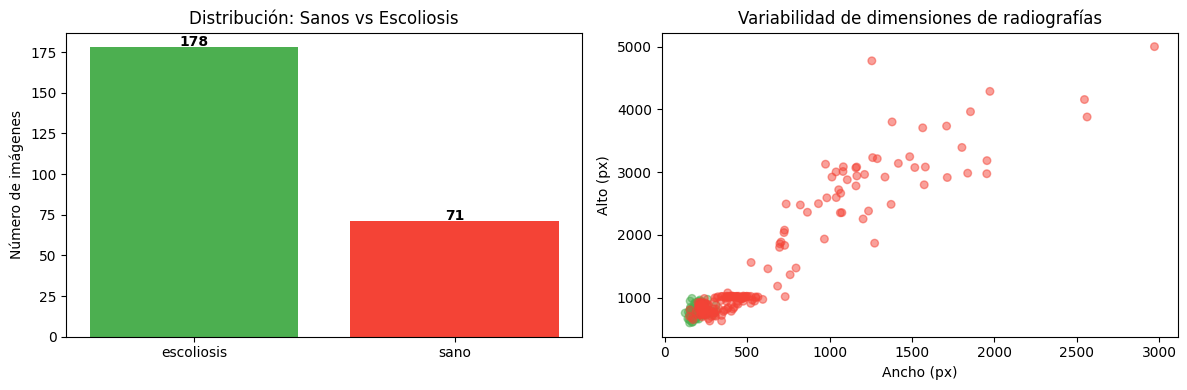

Estadísticas de dimensiones:
       ancho  alto
count    249   249
mean     519  1311
std      488   921
min      123   595
25%      212   782
50%      314   919
75%      551  1021
max     2972  4999


In [43]:
def get_size(ruta):
    try:
        img = Image.open(ruta)
        return img.width, img.height
    except:
        return None, None

df[['ancho', 'alto']] = df['ruta_img'].apply(lambda r: pd.Series(get_size(r)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

conteo = df['tipo'].value_counts()
axes[0].bar(conteo.index, conteo.values, color=['#4CAF50', '#F44336'])
axes[0].set_title('Distribución: Sanos vs Escoliosis')
axes[0].set_ylabel('Número de imágenes')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

col = df['tipo'].map({'sano': '#4CAF50', 'escoliosis': '#F44336'})
axes[1].scatter(df['ancho'], df['alto'], c=col, alpha=0.5, s=30)
axes[1].set_title('Variabilidad de dimensiones de radiografías')
axes[1].set_xlabel('Ancho (px)'); axes[1].set_ylabel('Alto (px)')

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'distribucion_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print('Estadísticas de dimensiones:')
print(df[['ancho','alto']].describe().round(0).astype(int))

### 3.2 Análisis del ángulo de Cobb

El **ángulo de Cobb** es la medida clínica estándar para cuantificar la severidad de la escoliosis. Se mide como el ángulo entre las líneas trazadas a lo largo de las vértebras más inclinadas de la curva espinal. Los criterios clínicos son:

- **< 10°** → Normal (sin escoliosis significativa)
- **10–24°** → Leve
- **25–39°** → Moderada (se recomienda tratamiento ortopédico)
- **≥ 40°** → Severa (se evalúa intervención quirúrgica)

El dataset incluye esta medición precalculada en los archivos `metrics_json/metrics_{id}.json`. Analizar su distribución permite entender si el modelo enfrentará principalmente casos leves o severos, y si hay suficiente representación de cada categoría para que el modelo generalice correctamente.

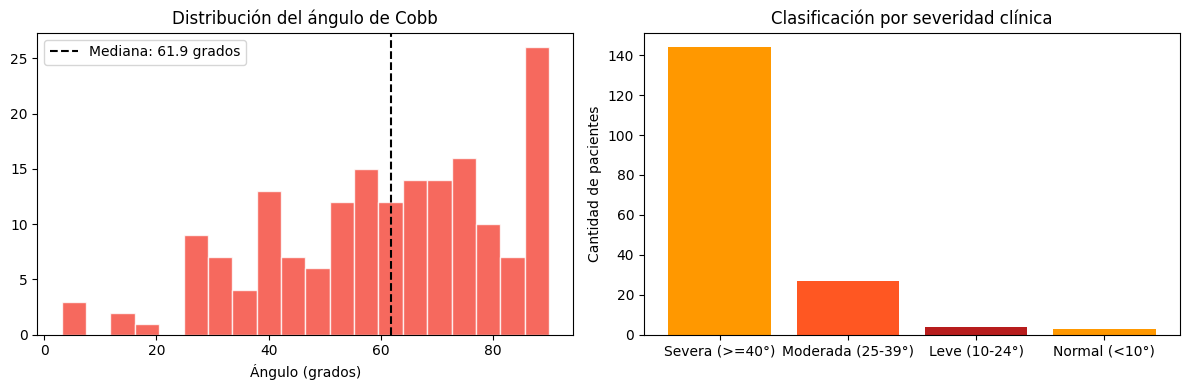

count    178.0
mean      61.0
std       20.9
min        3.1
25%       45.6
50%       61.9
75%       76.6
max       90.0
Name: cobb_deg, dtype: float64


In [44]:
cobbs = []
for _, f in df[df['tiene_metrics']].iterrows():
    try:
        with open(f['ruta_metrics']) as fh:
            m = json.load(fh)
        cobbs.append({'patient_id': f['patient_id'],
                      'cobb_deg': m.get('cobb_angle_deg', float('nan'))})
    except:
        pass

df_cobb = pd.DataFrame(cobbs)

def clasificar(deg):
    if deg < 10:   return 'Normal (<10°)'
    elif deg < 25: return 'Leve (10-24°)'
    elif deg < 40: return 'Moderada (25-39°)'
    else:          return 'Severa (>=40°)'

df_cobb['severidad'] = df_cobb['cobb_deg'].apply(clasificar)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
med = df_cobb['cobb_deg'].median()
axes[0].hist(df_cobb['cobb_deg'].dropna(), bins=20, color='#F44336', edgecolor='white', alpha=0.8)
axes[0].axvline(med, ls='--', color='k', label=f'Mediana: {med:.1f} grados')
axes[0].set_title('Distribución del ángulo de Cobb')
axes[0].set_xlabel('Ángulo (grados)'); axes[0].legend()

sc = df_cobb['severidad'].value_counts()
axes[1].bar(sc.index, sc.values, color=['#FF9800','#FF5722','#B71C1C'][:len(sc)])
axes[1].set_title('Clasificación por severidad clínica')
axes[1].set_ylabel('Cantidad de pacientes')

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'cobb_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()
print(df_cobb['cobb_deg'].describe().round(1))

### 3.3 Cobertura de vértebras en las máscaras

No todas las radiografías muestran la columna completa. Algunas son "incompletas" porque el encuadre del equipo radiológico cortó la parte superior o inferior de la columna. Para este proyecto esto es especialmente relevante, ya que uno de los **requisitos explícitos** es que el modelo funcione correctamente incluso con imágenes incompletas.

Esta celda analiza cuántas vértebras están anotadas en cada máscara y clasifica las imágenes según si contienen:
- Vértebras cervicales bajas (C3–C7, IDs 1–5)
- Vértebras torácicas (T1–T12, IDs 6–17)
- Vértebras lumbares (L1–L5, IDs 18–22)
- La columna T1–L5 completa (las 17 vértebras del proyecto)

La función lee la máscara como array `uint16` usando PIL (OpenCV trunca silenciosamente a `uint8`) y extrae los valores únicos de píxel, que corresponden directamente a los IDs del diccionario.

In [45]:
def analizar_mask(ruta_mask_id: str) -> dict:
    try:
        # PIL es obligatorio para leer uint16 sin truncamiento
        mask = np.array(Image.open(ruta_mask_id))
        vals = set(mask.flatten().tolist()) - {0}  # 0 = fondo
        return {
            'n_clases'        : len(vals),
            'vertebras'       : [MAPEO_ID.get(v, f'cls_{v}') for v in sorted(vals)],
            'tiene_cervicales': bool(vals & set(range(1, 6))),    # C3-C7
            'tiene_toracicas' : bool(vals & set(range(6, 18))),   # T1-T12
            'tiene_lumbares'  : bool(vals & set(range(18, 23))),  # L1-L5
            'T1_L5_completa'  : all(v in vals for v in range(6, 23)),
        }
    except Exception as e:
        return {'n_clases': 0, 'error': str(e)}

df_m = df[df['tiene_mask_id']].copy()
analisis = pd.DataFrame(df_m['ruta_mask_id'].apply(analizar_mask).tolist())
df_m = pd.concat([df_m.reset_index(drop=True), analisis], axis=1)

print('Cobertura de regiones vertebrales:')
for col, label in [
    ('tiene_cervicales', 'Con cervicales (C3-C7)    '),
    ('tiene_toracicas',  'Con toracicas (T1-T12)    '),
    ('tiene_lumbares',   'Con lumbares (L1-L5)      '),
    ('T1_L5_completa',   'T1-L5 completo            ')]:
    n = int(df_m[col].sum())
    pct = 100 * n / len(df_m)
    print(f'  {label}: {n}/{len(df_m)} ({pct:.0f}%)')
print()
print('Promedio de vertebras anotadas por imagen:')
print(df_m.groupby('tipo')['n_clases'].describe().round(1))

Cobertura de regiones vertebrales:
  Con cervicales (C3-C7)    : 212/249 (85%)
  Con toracicas (T1-T12)    : 248/249 (100%)
  Con lumbares (L1-L5)      : 164/249 (66%)
  T1-L5 completo            : 73/249 (29%)

Promedio de vertebras anotadas por imagen:
            count  mean  std   min   25%   50%   75%   max
tipo                                                      
escoliosis  178.0  14.2  3.8   0.0  12.0  15.0  17.0  21.0
sano         71.0  19.1  1.5  14.0  19.0  19.0  20.0  22.0


---
## 4. Inspección visual de imágenes y máscaras

La estadística es útil, pero nada reemplaza ver los datos directamente. Esta sección muestra muestras aleatorias de radiografías con sus máscaras superpuestas. Esto permite detectar problemas que los números no revelan: anotaciones mal alineadas, radiografías con artefactos, vértebras cuyas máscaras no cubren bien la silueta real, etc.

### 4.1 Muestras por tipo de paciente

Se visualizan 4 muestras de cada subgrupo (sanos y escoliosis). Para cada imagen se muestra:

- **Fila superior:** la radiografía original en escala de grises
- **Fila inferior:** la misma radiografía con la máscara multiclase superpuesta en colores. Cada color diferente representa una vértebra distinta. La transparencia parcial (alpha=0.55 para la imagen base, 0.6 para la máscara) permite ver simultáneamente la anatomía real y las anotaciones.

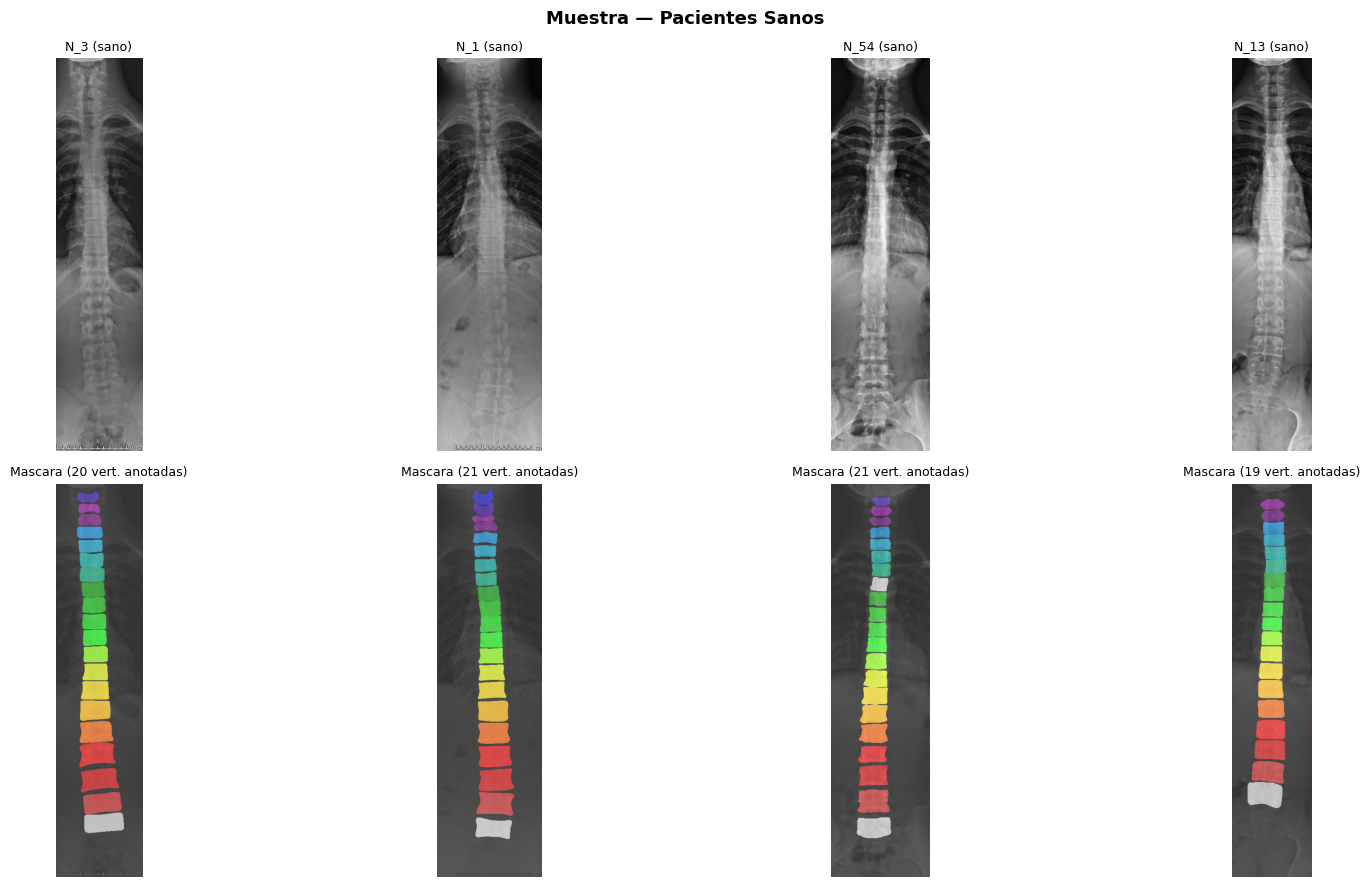

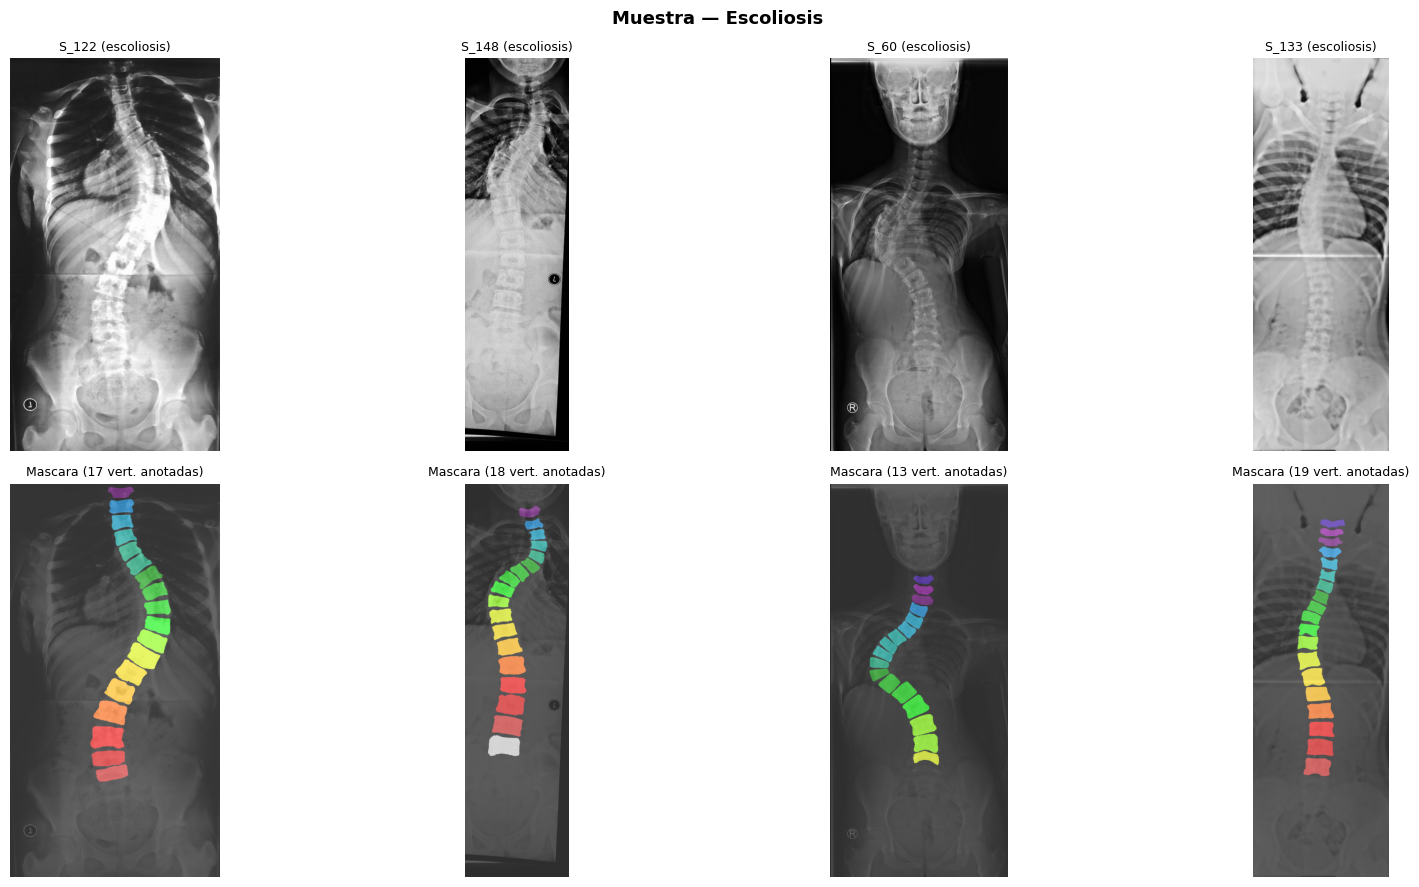

In [46]:
def visualizar(df_sub, n=4, titulo=''):
    sub = df_sub[df_sub['tiene_mask_id']].sample(min(n, len(df_sub)), random_state=SEED)
    if sub.empty:
        print('No hay imagenes con mascara en este subconjunto.')
        return
    fig, axes = plt.subplots(2, len(sub), figsize=(4.5 * len(sub), 9))
    if len(sub) == 1:
        axes = axes.reshape(2, 1)
    for col, (_, fila) in enumerate(sub.iterrows()):
        img  = np.array(Image.open(fila['ruta_img']).convert('L'))
        mask = np.array(Image.open(fila['ruta_mask_id']))  # uint16
        n_v  = len(set(mask.flatten()) - {0})
        axes[0, col].imshow(img, cmap='gray')
        axes[0, col].set_title(f"{fila['patient_id']} ({fila['tipo']})", fontsize=9)
        axes[0, col].axis('off')
        axes[1, col].imshow(img, cmap='gray', alpha=0.55)
        axes[1, col].imshow(mask, cmap='nipy_spectral', alpha=0.6, vmin=0, vmax=22)
        axes[1, col].set_title(f'Mascara ({n_v} vert. anotadas)', fontsize=9)
        axes[1, col].axis('off')
    plt.suptitle(titulo, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

visualizar(df[df['tipo'] == 'sano'],       n=4, titulo='Muestra — Pacientes Sanos')
visualizar(df[df['tipo'] == 'escoliosis'], n=4, titulo='Muestra — Escoliosis')

### 4.2 Comparación entre máscara binaria y máscara multiclase

El dataset incluye dos tipos de máscaras con propósitos diferentes:

- **Máscara binaria** (`LabelBinaryJPG/`): solo distingue *columna vertebral* (blanco=255) vs *fondo* (negro=0). Útil para detección global de la columna, pero no para segmentación de vértebras individuales.

- **Máscara multiclase ID** (`LabelMultiClass_ID_PNG/`): cada vértebra tiene un ID numérico único (1–22). Esta es la que se usa para entrenar, porque el objetivo del proyecto es identificar vértebras individuales, no la columna en bloque.

Esta celda superpone ambas para un mismo paciente, confirmando visualmente que las anotaciones están correctamente alineadas con la anatomía.

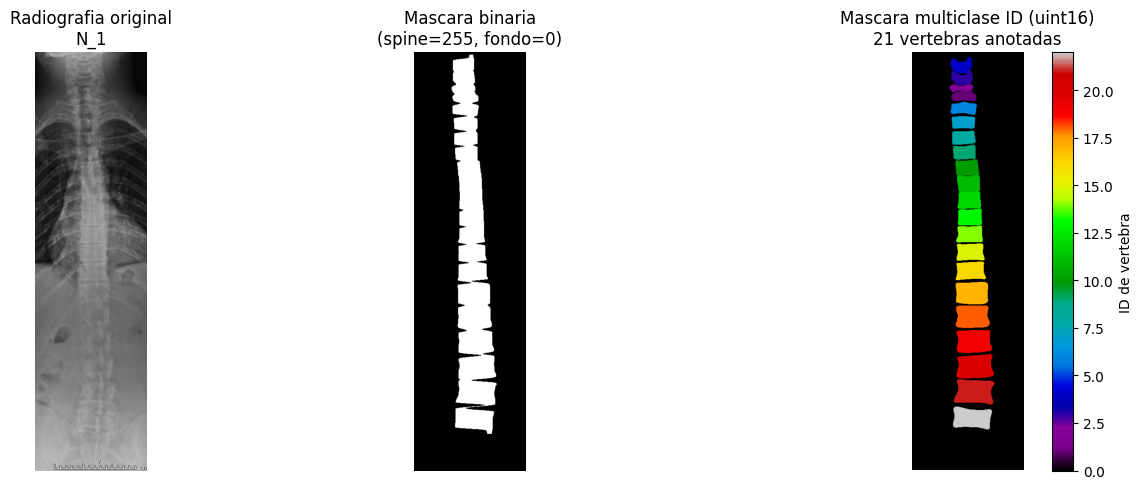

In [47]:
ej   = df[df['tiene_mask_id'] & df['tiene_mask_bin']].iloc[0]
img  = np.array(Image.open(ej['ruta_img']).convert('L'))
mbin = np.array(Image.open(ej['ruta_mask_bin']))
mid  = np.array(Image.open(ej['ruta_mask_id']))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title(f"Radiografia original\n{ej['patient_id']}")
axes[1].imshow(mbin, cmap='gray')
axes[1].set_title('Mascara binaria\n(spine=255, fondo=0)')
im = axes[2].imshow(mid, cmap='nipy_spectral', vmin=0, vmax=22)
n_v = len(set(mid.flatten()) - {0})
axes[2].set_title(f'Mascara multiclase ID (uint16)\n{n_v} vertebras anotadas')
plt.colorbar(im, ax=axes[2], label='ID de vertebra')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'comparacion_mascaras.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Control de calidad

Esta sección busca activamente problemas en el dataset que podrían corromper el entrenamiento. La función `verificar()` revisa cada imagen y sus archivos asociados, reportando los siguientes tipos de problemas:

- **Resolución baja** (< 256×256 px): imágenes tan pequeñas que el modelo no podría aprender patrones anatómicos útiles.
- **Imagen uniforme** (desviación estándar de píxeles < 5): indicio de imagen corrupta, en blanco, o completamente negra.
- **Sin máscara multiclase**: la imagen existe pero no tiene su anotación; no puede usarse para entrenamiento supervisado.
- **Desalineación imagen/máscara**: la máscara tiene dimensiones distintas a la imagen. Aunque ambas se redimensionarán más adelante, una discrepancia aquí podría indicar que la máscara corresponde a otro paciente.
- **Máscara vacía**: la máscara existe pero todos sus píxeles son 0 (solo fondo), lo que significa que no hay ninguna vértebra anotada.

Las imágenes que presenten problemas graves se excluyen del dataset limpio (`df_ok`) utilizado en los pasos siguientes.

In [48]:
def verificar(fila):
    issues = []
    try:
        img = np.array(Image.open(fila['ruta_img']).convert('L'))
        h, w = img.shape
        if min(h, w) < 256:
            issues.append(f'Resolucion baja: {w}x{h} px')
        if img.std() < 5:
            issues.append('Imagen casi uniforme (posible corrupcion)')
    except Exception as e:
        issues.append(f'No se puede leer la imagen: {e}')
        return issues

    if not fila['tiene_mask_id']:
        issues.append('Falta la mascara multiclase ID PNG')
    else:
        try:
            mask = np.array(Image.open(fila['ruta_mask_id']))
            if mask.shape != (h, w):
                issues.append(f'Shape imagen ({w}x{h}) != mascara ({mask.shape[1]}x{mask.shape[0]})')
            if mask.max() == 0:
                issues.append('Mascara completamente vacia (cero vertebras anotadas)')
        except Exception as e:
            issues.append(f'No se puede leer la mascara: {e}')
    return issues

df['issues']   = [verificar(f) for _, f in tqdm(df.iterrows(), total=len(df), desc='Verificando')]
df['n_issues'] = df['issues'].apply(len)

df_ok  = df[df['n_issues'] == 0].copy()
df_bad = df[df['n_issues'] >  0].copy()

print(f'Imagenes sin problemas : {len(df_ok)}')
print(f'Imagenes con problemas : {len(df_bad)}')
if not df_bad.empty:
    print()
    for _, r in df_bad.iterrows():
        pid = r['patient_id']
        iss = r['issues']
        print(f'  [{pid}] -> {iss}')

Verificando: 100%|██████████| 249/249 [00:01<00:00, 179.87it/s]

Imagenes sin problemas : 148
Imagenes con problemas : 101

  [N_11] -> ['Resolucion baja: 181x727 px']
  [N_12] -> ['Resolucion baja: 164x986 px']
  [N_13] -> ['Resolucion baja: 149x736 px']
  [N_14] -> ['Resolucion baja: 169x734 px']
  [N_15] -> ['Resolucion baja: 177x692 px']
  [N_17] -> ['Resolucion baja: 211x918 px']
  [N_18] -> ['Resolucion baja: 164x782 px']
  [N_19] -> ['Resolucion baja: 232x852 px']
  [N_2] -> ['Resolucion baja: 218x828 px']
  [N_20] -> ['Resolucion baja: 212x960 px']
  [N_21] -> ['Resolucion baja: 182x719 px']
  [N_22] -> ['Resolucion baja: 205x929 px']
  [N_23] -> ['Resolucion baja: 241x878 px']
  [N_24] -> ['Resolucion baja: 164x606 px']
  [N_25] -> ['Resolucion baja: 155x817 px']
  [N_26] -> ['Resolucion baja: 157x679 px']
  [N_27] -> ['Resolucion baja: 187x672 px']
  [N_28] -> ['Resolucion baja: 165x780 px']
  [N_29] -> ['Resolucion baja: 155x844 px']
  [N_3] -> ['Resolucion baja: 206x939 px']
  [N_30] -> ['Resolucion baja: 201x846 px']
  [N_31] -> ['Resol

---
## 6. Normalización y preprocesamiento

Antes de alimentar las imágenes a los modelos es necesario aplicar un preprocesamiento estándar. Las radiografías tienen tamaños variables, pero cada modelo de deep learning espera imágenes de un tamaño fijo. Además, el contraste varía significativamente entre distintos equipos de rayos X.

### Preprocesamiento de imágenes (`preproc_img`)

Se aplican tres operaciones en secuencia:

**1. Conversión a escala de grises.** Las radiografías son imágenes monocanal; no tienen información de color. Se unifica el formato leyendo directamente en grises.

**2. CLAHE** (*Contrast Limited Adaptive Histogram Equalization*). Técnica de mejora de contraste diseñada para imágenes médicas. A diferencia de la ecualización de histograma global, CLAHE actúa en pequeñas regiones locales (tiles de 8×8 px), realzando detalles tanto en áreas brillantes como en áreas oscuras sin saturar zonas uniformes. Es especialmente útil en radiografías donde la región torácica y la lumbar tienen densidades muy distintas.

**3. Letterbox resize.** Se escala la imagen manteniendo su proporción original (aspect ratio) y se añade padding negro en los bordes para alcanzar el tamaño cuadrado exacto que espera el modelo. Esto evita deformar la anatomía: estirar o comprimir vértebras verticalmente afectaría negativamente al aprendizaje.

### Preprocesamiento de máscaras (`preproc_mask`)

La máscara se redimensiona con el mismo letterbox, pero usando **interpolación nearest** (vecino más cercano). Esto es crítico: si se usara interpolación bilineal, los píxeles en el borde entre dos vértebras adyacentes recibirían valores intermedios (por ejemplo, 6.5 entre `T1=6` y `T2=7`) que no corresponden a ninguna vértebra real. Con nearest, cada píxel de la máscara redimensionada conserva exactamente el ID original.

### Tamaños objetivo por modelo

| Modelo | Tamaño | Justificación |
|---|---|---|
| YOLO11m-seg | 640×640 | Resolución óptima según documentación Ultralytics |
| SegFormer-B2 | 512×512 | Tamaño estándar del backbone MiT-B2 |
| MedSAM | 1024×1024 | SAM fue preentrenado con imágenes de 1024×1024 |

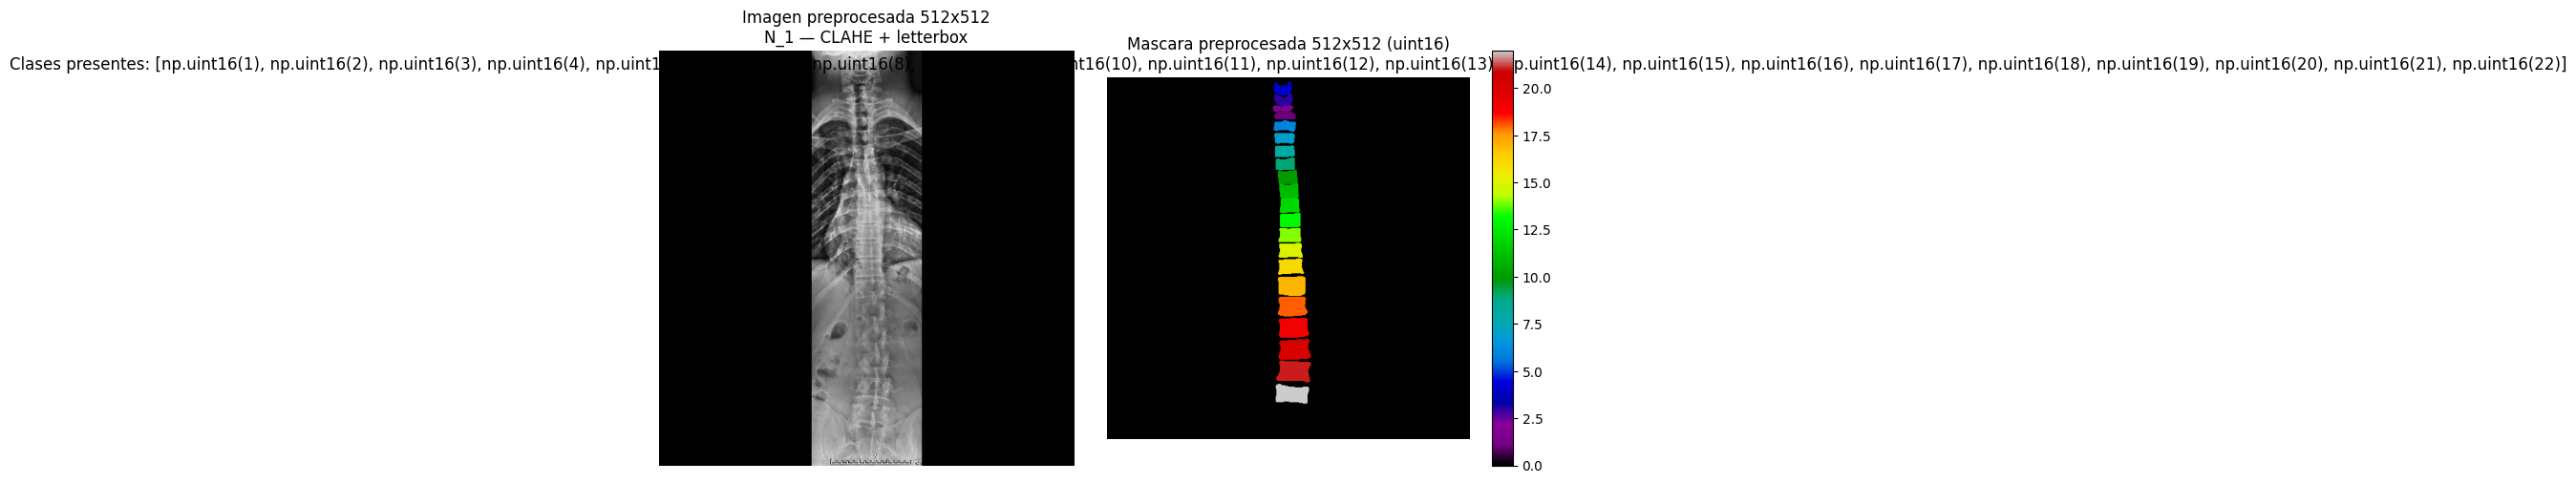

Imagen  -> shape=(512, 512), rango=[0.00, 1.00]
Mascara -> dtype=uint16, shape=(512, 512)


In [49]:
CONFIGS = {
    'yolo'     : (640,  640),
    'segformer': (512,  512),
    'medsam'   : (1024, 1024),
}

def preproc_img(ruta: str, size: tuple) -> np.ndarray:
    """
    Pipeline de preprocesamiento de radiografía:
      1. Lectura en escala de grises
      2. CLAHE (mejora contraste local)
      3. Letterbox resize (mantiene aspecto + padding negro)
      4. Normalización a float32 en [0, 1]
    """
    img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f'No se pudo leer: {ruta}')

    # CLAHE: mejora el contraste local sin saturar zonas uniformes
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    # Letterbox: escalar con el factor que no supere ninguna dimensión
    th, tw = size
    h, w   = img.shape
    s      = min(tw / w, th / h)
    nw, nh = int(w * s), int(h * s)
    img_r  = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_LANCZOS4)

    # Centrar la imagen escalada en un canvas de padding negro
    canvas = np.zeros((th, tw), np.uint8)
    yo, xo = (th - nh) // 2, (tw - nw) // 2
    canvas[yo:yo+nh, xo:xo+nw] = img_r

    return canvas.astype(np.float32) / 255.0


def preproc_mask(ruta: str, size: tuple) -> np.ndarray:
    """
    Redimensiona la mascara uint16 con interpolacion NEAREST.
    NEAREST es obligatorio: preserva los IDs exactos de vertebras.
    PIL maneja uint16 correctamente; cv2 lo truncaria a uint8.
    """
    mask  = np.array(Image.open(ruta))   # uint16
    th, tw = size
    h, w   = mask.shape
    s      = min(tw / w, th / h)
    nw, nh = int(w * s), int(h * s)
    m_r    = np.array(Image.fromarray(mask).resize((nw, nh), Image.NEAREST))

    canvas = np.zeros((th, tw), np.uint16)
    yo, xo = (th - nh) // 2, (tw - nw) // 2
    canvas[yo:yo+nh, xo:xo+nw] = m_r
    return canvas


# Verificacion visual con la primera imagen del dataset limpio
ej = df_ok.iloc[0]
ip = preproc_img(ej['ruta_img'], (512, 512))
mp = preproc_mask(ej['ruta_mask_id'], (512, 512))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(ip, cmap='gray')
axes[0].set_title(f"Imagen preprocesada 512x512\n{ej['patient_id']} — CLAHE + letterbox")
im = axes[1].imshow(mp, cmap='nipy_spectral', vmin=0, vmax=22)
axes[1].set_title(f'Mascara preprocesada 512x512 (uint16)\nClases presentes: {sorted(set(mp.flatten())-{0})}')
plt.colorbar(im, ax=axes[1])
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()
print(f'Imagen  -> shape={ip.shape}, rango=[{ip.min():.2f}, {ip.max():.2f}]')
print(f'Mascara -> dtype={mp.dtype}, shape={mp.shape}')

---
## 7. División train / val / test

### ¿Por qué dividir el dataset?

En aprendizaje supervisado el dataset se divide en tres subconjuntos con propósitos distintos:

- **Train (70%):** las imágenes que el modelo ve durante el entrenamiento para ajustar sus pesos. Cuantas más, mejor para el aprendizaje.
- **Val (15%):** imágenes que el modelo *no* ve durante el entrenamiento, pero que se usan al final de cada época para medir el rendimiento. Guía la selección del mejor checkpoint y el ajuste de hiperparámetros.
- **Test (15%):** imágenes que el modelo nunca ha visto en ningún momento del proceso. Solo se usan al final, una única vez, para reportar las métricas finales (Dice, IoU). Si se usara val como test, los resultados estarían sesgados porque las decisiones de entrenamiento se tomaron mirando ese conjunto.

### Estratificación por tipo de paciente

Con solo ~250 imágenes totales, una división puramente aleatoria podría generar por azar un conjunto de test con muchos más sanos que escoliosis (o viceversa), haciendo las métricas de evaluación poco representativas.

`train_test_split` con `stratify=df['tipo']` garantiza que la proporción sanos/escoliosis (~28%/72%) se mantenga exactamente igual en los tres subconjuntos.

In [50]:
df_limpio = df_ok[df_ok['tiene_mask_id']].copy().reset_index(drop=True)
print(f'Dataset limpio total: {len(df_limpio)} imagenes')
print(df_limpio['tipo'].value_counts())
print()

# Paso 1: separar 70% train del 30% restante, manteniendo la proporcion de clases
df_tr, df_vt = train_test_split(
    df_limpio, test_size=0.30,
    stratify=df_limpio['tipo'], random_state=SEED)

# Paso 2: dividir el 30% restante en mitades iguales (15% val + 15% test)
df_val, df_te = train_test_split(
    df_vt, test_size=0.50,
    stratify=df_vt['tipo'], random_state=SEED)

df_tr  = df_tr.copy();  df_tr['split']  = 'train'
df_val = df_val.copy(); df_val['split'] = 'val'
df_te  = df_te.copy();  df_te['split']  = 'test'
df_splits = pd.concat([df_tr, df_val, df_te], ignore_index=True)

# Verificar que la estratificacion funcionó correctamente
tabla = (df_splits
         .groupby(['split', 'tipo']).size()
         .unstack(fill_value=0)
         .reindex(['train', 'val', 'test']))
print('Distribucion por split y tipo:')
print(tabla)
print()
print(f'Totales -> train={len(df_tr)} | val={len(df_val)} | test={len(df_te)}')

# Guardar CSV para reproducibilidad futura
csv_path = OUTPUT_ROOT / 'splits.csv'
df_splits[['patient_id', 'tipo', 'split', 'ruta_img', 'ruta_mask_id']].to_csv(csv_path, index=False)
print(f'splits.csv guardado en: {csv_path}')

Dataset limpio total: 148 imagenes
tipo
escoliosis    142
sano            6
Name: count, dtype: int64

Distribucion por split y tipo:
tipo   escoliosis  sano
split                  
train          99     4
val            21     1
test           22     1

Totales -> train=103 | val=22 | test=23
splits.csv guardado en: /Users/anferiro/Library/Mobile Documents/com~apple~CloudDocs/personal/maia/proyecto/columna/recursos/dataset_procesado/splits.csv


---
## 8. Exportación en formatos por modelo

Cada uno de los tres modelos espera los datos en un formato diferente. Esta sección convierte el dataset limpio y dividido en tres directorios independientes.

### Formato YOLO (YOLO11m-seg)

YOLO espera las anotaciones de segmentación como **archivos de texto** (`.txt`), uno por imagen, donde cada línea describe una instancia de objeto con el formato:

```
clase_idx  x1 y1  x2 y2  x3 y3 ... xn yn
```

Las coordenadas son los vértices del **contorno del polígono** que delimita cada vértebra, normalizados al rango [0, 1]. El `clase_idx` es `ID_vertebra - 1` porque YOLO usa indexación 0-based. Para obtener los polígonos se usa `cv2.findContours()` aplicado a una máscara binaria de cada vértebra por separado.

### Formato SegFormer (HuggingFace)

SegFormer espera las anotaciones como **imágenes PNG de píxel entero**, donde cada valor de píxel indica la clase (0=fondo, 1–22=vértebras). Las máscaras `uint16` se convierten a `uint8` sin pérdida de información, ya que los IDs no superan el valor 22.

### Formato MedSAM

SAM no hace segmentación automática; necesita **prompts** que le indiquen qué segmentar. Se usan **bounding boxes** como prompts, derivados directamente de cada máscara. La exportación genera un archivo `prompts.json` por split con las coordenadas `[x_min, y_min, x_max, y_max]` de cada vértebra. Las imágenes se exportan en RGB aunque sean en grises, porque SAM espera 3 canales.

In [51]:
def mask_to_yolo_polys(mask: np.ndarray, h: int, w: int) -> list:
    """
    Convierte mascara uint16 multiclase al formato YOLO segmentation.
    Cada linea: 'clase_idx x1 y1 x2 y2 ... xn yn'  (coords normalizadas)
    clase_idx = ID_vertebra - 1  (YOLO usa indexacion 0-based)
    """
    lines = []
    for id_v in sorted(set(mask.flatten().tolist()) - {0}):
        cls      = int(id_v) - 1
        bin_mask = (mask == id_v).astype(np.uint8) * 255
        cnts, _  = cv2.findContours(bin_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in cnts:
            if c.shape[0] < 3: continue
            pts = c.squeeze()
            if pts.ndim == 1: continue
            coords = ' '.join(f'{x/w:.6f} {y/h:.6f}' for x, y in pts)
            lines.append(f'{cls} {coords}')
    return lines


def export_yolo(df_sub, split, size, out):
    """Exporta imagenes (PNG) y etiquetas (TXT con poligonos) para YOLO."""
    (out / split / 'images').mkdir(parents=True, exist_ok=True)
    (out / split / 'labels').mkdir(parents=True, exist_ok=True)
    for _, f in tqdm(df_sub.iterrows(), total=len(df_sub), desc=f'YOLO-{split}'):
        img  = preproc_img(f['ruta_img'], size)
        mask = preproc_mask(f['ruta_mask_id'], size)
        pid  = f['patient_id']
        cv2.imwrite(str(out / split / 'images' / f'{pid}.png'), (img * 255).astype(np.uint8))
        th, tw = size
        (out / split / 'labels' / f'{pid}.txt').write_text(
            '\n'.join(mask_to_yolo_polys(mask, th, tw)))


def export_segformer(df_sub, split, size, out):
    """Exporta imagenes y mascaras (PNG uint8) para SegFormer de HuggingFace."""
    (out / split / 'images').mkdir(parents=True, exist_ok=True)
    (out / split / 'annotations').mkdir(parents=True, exist_ok=True)
    for _, f in tqdm(df_sub.iterrows(), total=len(df_sub), desc=f'SegFormer-{split}'):
        img  = preproc_img(f['ruta_img'], size)
        mask = preproc_mask(f['ruta_mask_id'], size)   # uint16
        pid  = f['patient_id']
        cv2.imwrite(str(out / split / 'images' / f'{pid}.png'), (img * 255).astype(np.uint8))
        # Convertir uint16 a uint8: IDs <= 22, no hay perdida de informacion
        Image.fromarray(mask.astype(np.uint8)).save(
            str(out / split / 'annotations' / f'{pid}.png'))


def export_medsam(df_sub, split, size, out):
    """Exporta imagenes RGB, mascaras y bounding boxes (prompts) para MedSAM."""
    (out / split / 'images').mkdir(parents=True, exist_ok=True)
    (out / split / 'masks').mkdir(parents=True, exist_ok=True)
    prompts = []
    for _, f in tqdm(df_sub.iterrows(), total=len(df_sub), desc=f'MedSAM-{split}'):
        img  = preproc_img(f['ruta_img'], size)
        mask = preproc_mask(f['ruta_mask_id'], size)
        pid  = f['patient_id']
        # SAM espera RGB: duplicar el canal gris en 3 canales
        rgb  = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
        cv2.imwrite(str(out / split / 'images' / f'{pid}.png'), rgb)
        Image.fromarray(mask).save(str(out / split / 'masks' / f'{pid}.png'))
        # Bounding box por vertebra como prompt de SAM
        bboxes = {}
        for id_v in sorted(set(mask.flatten().tolist()) - {0}):
            ys, xs = np.where(mask == id_v)
            bboxes[int(id_v)] = {
                'vertebra' : MAPEO_ID.get(int(id_v), f'cls_{id_v}'),
                'bbox_xyxy': [int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())]
            }
        prompts.append({'patient_id': pid, 'prompts': bboxes})
    with open(out / split / 'prompts.json', 'w') as fh:
        json.dump(prompts, fh, indent=2, ensure_ascii=False)

print('Funciones de exportacion definidas correctamente')

Funciones de exportacion definidas correctamente


### Ejecutar la exportación

Las siguientes dos celdas ejecutan las funciones anteriores para los tres modelos y generan el archivo `dataset.yaml` que YOLO necesita para localizar las imágenes y conocer el número de clases y sus nombres.

> ⚠️ Este proceso puede tardar varios minutos porque procesa y guarda ~750 imágenes (250 originales × 3 modelos), cada una redimensionada a un tamaño diferente y en el formato correspondiente.

In [52]:
# Ejecutar exportacion para los tres modelos y todos los splits
EXPORTS = [('train', df_tr), ('val', df_val), ('test', df_te)]

for modelo, size in CONFIGS.items():
    print(f'\n{"="*50}')
    print(f'Exportando {modelo.upper()} — {size[0]}x{size[1]} px')
    print('=' * 50)
    out = OUTPUT_ROOT / modelo
    for sname, dsub in EXPORTS:
        if   modelo == 'yolo':       export_yolo(dsub, sname, size, out)
        elif modelo == 'segformer':  export_segformer(dsub, sname, size, out)
        elif modelo == 'medsam':     export_medsam(dsub, sname, size, out)

print('\nExportacion completa para los tres modelos.')


Exportando YOLO — 640x640 px


YOLO-test: 100%|██████████| 23/23 [00:00<00:00, 66.41it/s]



Exportando SEGFORMER — 512x512 px


SegFormer-test: 100%|██████████| 23/23 [00:00<00:00, 93.84it/s] 



Exportando MEDSAM — 1024x1024 px


MedSAM-test: 100%|██████████| 23/23 [00:01<00:00, 18.90it/s]


Exportacion completa para los tres modelos.


In [53]:
# Generar dataset.yaml para YOLO11m-seg
# Este archivo es obligatorio: le indica a YOLO donde estan las imagenes,
# cuantas clases hay y cuales son sus nombres.
yaml_lines = [
    '# Dataset: Segmentacion columna vertebral MaIA',
    f'# Generado: {pd.Timestamp.now().date()}',
    f'path: {OUTPUT_ROOT / "yolo"}',
    'train: train/images',
    'val:   val/images',
    'test:  test/images',
    f'nc: {N_CLASES}',
    f'names: {NOMBRES_CLASES}',
]
yaml_txt = '\n'.join(yaml_lines)
yp = OUTPUT_ROOT / 'yolo' / 'dataset.yaml'
yp.parent.mkdir(parents=True, exist_ok=True)
yp.write_text(yaml_txt)
print('dataset.yaml guardado')
print()
print(yaml_txt)

dataset.yaml guardado

# Dataset: Segmentacion columna vertebral MaIA
# Generado: 2026-03-29
path: /Users/anferiro/Library/Mobile Documents/com~apple~CloudDocs/personal/maia/proyecto/columna/recursos/dataset_procesado/yolo
train: train/images
val:   val/images
test:  test/images
nc: 22
names: ['C7', 'C6', 'C5', 'C4', 'C3', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'L1', 'L2', 'L3', 'L4', 'L5']


---
## 9. Resumen y próximos pasos

Esta última celda guarda un archivo `metadata.json` con un registro completo de todo lo realizado en este notebook: cuántas imágenes se procesaron, cómo se distribuyeron en los splits, qué clases se incluyeron, con qué configuración de preprocesamiento y en qué fecha.

Este archivo sirve como **trazabilidad del experimento**. Si en el futuro se necesita reproducir exactamente el mismo preprocesamiento —por ejemplo, al comparar con un nuevo modelo o al reentrenar con más datos— basta con leer este JSON para saber exactamente qué se hizo.

In [54]:
meta = {
    'fecha'         : str(pd.Timestamp.now()),
    'tarea_clickup' : '86aggyj9m — Recoleccion y preparacion de datos',
    'dataset'       : 'MaIA_Scoliosis_Dataset',
    'estructura_dataset': {
        'imagenes_sanos'     : 'Normal/N_{id}.jpg',
        'imagenes_escoliosis': 'Scoliosis/S_{id}.jpg',
        'mascaras_id_png'    : 'LabelMultiClass_ID_PNG/LabelMulti_{N|S}_{id}.png (uint16)',
        'mascaras_binarias'  : 'LabelBinaryJPG/Label_{N|S}_{id}.jpg',
        'metricas_cobb'      : 'RadiographMetrics/metrics_json/metrics_{num}.json',
    },
    'totales': {
        'sanos'     : int((df['tipo'] == 'sano').sum()),
        'escoliosis': int((df['tipo'] == 'escoliosis').sum()),
        'limpio'    : len(df_limpio),
        'train'     : len(df_tr),
        'val'       : len(df_val),
        'test'      : len(df_te),
    },
    'preprocesamiento': {
        'imagen' : 'escala de grises + CLAHE (clipLimit=2, tile=8x8) + letterbox + norm [0,1]',
        'mascara': 'letterbox + interpolacion NEAREST (uint16)',
    },
    'clases'  : {'n': N_CLASES, 'nombres': NOMBRES_CLASES},
    'modelos' : {m: {'size': list(s)} for m, s in CONFIGS.items()},
    'seed'    : SEED,
}

with open(OUTPUT_ROOT / 'metadata.json', 'w') as fh:
    json.dump(meta, fh, indent=2, ensure_ascii=False, default=str)

t = meta['totales']
print('=' * 65)
print('  RESUMEN FINAL — RECOLECCION Y PREPARACION DE DATOS')
print('=' * 65)
print(f"  Sanos                : {t['sanos']}  (Normal/N_{{id}}.jpg)")
print(f"  Escoliosis           : {t['escoliosis']} (Scoliosis/S_{{id}}.jpg)")
print(f"  Dataset limpio       : {t['limpio']} (pasaron control de calidad)")
print(f"  Train                : {t['train']} imagenes  (70%)")
print(f"  Val                  : {t['val']}  imagenes  (15%)")
print(f"  Test                 : {t['test']}  imagenes  (15%)")
print(f"  Clases               : {N_CLASES} (C3-C7, T1-T12, L1-L5)")
print(f"  Exportados           : yolo(640x640) | segformer(512x512) | medsam(1024x1024)")
print()
print('  PROXIMOS PASOS (Tarea 86aggyjbb — Construccion del modelo):')
print('  1. Decidir si incluir cervicales (C3-C7) o restringir a T1-L5')
print('     Impacta la definicion de N_CLASES y los umbrales de evaluacion')
print('  2. Implementar data augmentation (flips, rotacion leve, variacion de brillo)')
print('     Especialmente importante por el bajo N (~250 imagenes)')
print('  3. Iniciar notebook de entrenamiento de YOLO11m-seg como baseline')
print('=' * 65)

  RESUMEN FINAL — RECOLECCION Y PREPARACION DE DATOS
  Sanos                : 71  (Normal/N_{id}.jpg)
  Escoliosis           : 178 (Scoliosis/S_{id}.jpg)
  Dataset limpio       : 148 (pasaron control de calidad)
  Train                : 103 imagenes  (70%)
  Val                  : 22  imagenes  (15%)
  Test                 : 23  imagenes  (15%)
  Clases               : 22 (C3-C7, T1-T12, L1-L5)
  Exportados           : yolo(640x640) | segformer(512x512) | medsam(1024x1024)

  PROXIMOS PASOS (Tarea 86aggyjbb — Construccion del modelo):
  1. Decidir si incluir cervicales (C3-C7) o restringir a T1-L5
     Impacta la definicion de N_CLASES y los umbrales de evaluacion
  2. Implementar data augmentation (flips, rotacion leve, variacion de brillo)
     Especialmente importante por el bajo N (~250 imagenes)
  3. Iniciar notebook de entrenamiento de YOLO11m-seg como baseline
